# Exp B-1 — Pre-processing Perturbation Stress Test

**Hypothesis:** Smart M degrades gracefully within bounded MI noise — sharp degradation quantifies dependency limits.

Protocol:
- Dataset: Elliptic Bitcoin (only the success case)
- Inject Gaussian noise σ ∈ {0, 0.05, 0.1, 0.2, 0.5, 1.0} into MI estimates before building Smart M
- Also test cluster assignment noise (random label swap rate p ∈ {0, 0.1, 0.2, 0.3})
- Metric: PR-AUC from AISO(noisy M) → LR eval (Exp 5 protocol, fast)
- 5 seeds per noise level

**Kernel:** .venv

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import roc_auc_score, average_precision_score

DATA_DIR  = Path('../Elliptic Bitcoin/elliptic_bitcoin_dataset')
K_SELECT  = 20
N_TYPES   = 15
SEEDS     = [0, 7, 42, 77, 123]
GAMMA     = 0.5

print('imports ok')

imports ok


In [2]:
feat_df = pd.read_csv(DATA_DIR / 'elliptic_txs_features.csv', header=None)
cls_df  = pd.read_csv(DATA_DIR / 'elliptic_txs_classes.csv')
N_FEAT  = feat_df.shape[1] - 2
feat_df.columns = ['txId','timestep'] + [f'f{i}' for i in range(N_FEAT)]
cls_df.columns  = ['txId','class']
df = feat_df.merge(cls_df, on='txId')
df = df[df['class'] != 'unknown'].copy()
df['label'] = (df['class'] == '1').astype(int)
train_df = df[df['timestep'] <= 34]
test_df  = df[df['timestep'] >  34]
fc = [f'f{i}' for i in range(N_FEAT)]
X_train, y_train = train_df[fc].values.astype(float), train_df['label'].values
X_test,  y_test  = test_df[fc].values.astype(float),  test_df['label'].values

# Base MI and clustering
print('Computing base MI and clustering...')
C_abs = np.abs(np.corrcoef(X_train.T))
dist_mx = 1.0 - C_abs; np.fill_diagonal(dist_mx, 0.0)
base_cluster = AgglomerativeClustering(n_clusters=N_TYPES, metric='precomputed', linkage='average')
base_labels  = base_cluster.fit_predict(dist_mx)
base_MI      = mutual_info_classif(X_train, y_train, random_state=42)
print(f'MI range: [{base_MI.min():.4f}, {base_MI.max():.4f}]')

Computing base MI and clustering...
MI range: [0.0039, 0.2303]


In [3]:
def build_smart_M(MI, cluster_labels, C_abs, gamma=GAMMA):
    K = N_TYPES
    mean_MI = np.array([MI[cluster_labels == k].mean() if (cluster_labels == k).any() else 0.0 for k in range(K)])
    MI_norm = (mean_MI - mean_MI.min()) / (mean_MI.max() - mean_MI.min() + 1e-8)
    M = np.zeros((K, K))
    for i in range(K):
        for j in range(K):
            fi = np.where(cluster_labels == i)[0]
            fj = np.where(cluster_labels == j)[0]
            M[i, j] = -1.0 if i == j else -np.mean(C_abs[np.ix_(fi, fj)]) + gamma * (MI_norm[j] - MI_norm[i])
    return M


def evaluate(feat_idx, seed=42):
    lr = LogisticRegression(class_weight='balanced', max_iter=500, random_state=seed, C=1.0)
    lr.fit(X_train[:, feat_idx], y_train)
    proba = lr.predict_proba(X_test[:, feat_idx])[:, 1]
    return average_precision_score(y_test, proba)


class AISOwrapper:
    def __init__(self, n_agents=20, n_iter=80, beta=0.15, subsample_ratio=0.15, val_ratio=0.2, T_start=1.0, T_end=0.05):
        self.n_agents=n_agents; self.n_iter=n_iter; self.beta=beta
        self.subsample_ratio=subsample_ratio; self.val_ratio=val_ratio
        self.T_start=T_start; self.T_end=T_end

    def select(self, X, y, cluster_labels, K_select, M, seed=42):
        rng = np.random.RandomState(seed)
        N, D = X.shape; K = M.shape[0]; nb = min(3, self.n_agents-1)
        val_n = int(self.val_ratio*N); val_idx = rng.choice(N, val_n, replace=False)
        tr_mask = np.ones(N, bool); tr_mask[val_idx] = False
        X_val, y_val = X[val_idx], y[val_idx]
        X_t,   y_t   = X[tr_mask], y[tr_mask]
        proxy = SGDClassifier(loss='log_loss', max_iter=5, tol=None, class_weight='balanced', random_state=seed)
        cache = {}; sub_n = max(50, int(self.subsample_ratio*len(X_t)))

        def get_mask(Wi, t, explore=True):
            if explore:
                ratio = t/max(1, self.n_iter-1)
                T = self.T_start*((self.T_end/self.T_start)**ratio)
                logits = Wi[cluster_labels]/T; logits -= logits.max()
                probs = np.exp(logits); probs /= probs.sum()
                return tuple(rng.choice(D, K_select, replace=False, p=probs))
            return tuple(np.argsort(Wi[cluster_labels])[-K_select:])

        def get_score(mk, X_sub, y_sub):
            if mk in cache: return cache[mk]
            try:
                proxy.fit(X_sub[:, list(mk)], y_sub)
                proba = proxy.predict_proba(X_val[:, list(mk)])[:, 1]
                s = roc_auc_score(y_val, proba)
            except: s = 0.5
            cache[mk] = s; return s

        W = rng.dirichlet(np.ones(K), self.n_agents)
        for i in range(self.n_agents):
            sub = rng.choice(len(X_t), sub_n, replace=False)
            get_score(get_mask(W[i], 0), X_t[sub], y_t[sub])

        for t in range(self.n_iter):
            Cm = W @ M @ W.T; np.fill_diagonal(Cm, 0.0)
            sub = rng.choice(len(X_t), sub_n, replace=False)
            X_sub, y_sub = X_t[sub], y_t[sub]
            for i in range(self.n_agents):
                att = np.argsort(Cm[i])[-nb:]
                att_s = np.array([get_score(get_mask(W[j], t), X_sub, y_sub) for j in att])
                bj = att[np.argmax(Cm[i, att]*att_s/(att_s.max()+1e-8))]
                W_new = (1-self.beta)*W[i]+self.beta*W[bj]; W[i] = W_new/W_new.sum()

        final_lr = LogisticRegression(solver='liblinear', C=1.0, max_iter=500, class_weight='balanced', random_state=seed)
        fseen, fs = {}, []
        for i in range(self.n_agents):
            mk = get_mask(W[i], self.n_iter, explore=False)
            if mk not in fseen:
                final_lr.fit(X_t[:, list(mk)], y_t)
                proba = final_lr.predict_proba(X_val[:, list(mk)])[:, 1]
                fseen[mk] = roc_auc_score(y_val, proba)
            fs.append(fseen[mk])
        return np.array(list(get_mask(W[np.argmax(fs)], self.n_iter, explore=False)))


wrapper = AISOwrapper()
print('Ready')

Ready


## B-1a: MI Noise

In [4]:
MI_NOISE_LEVELS = [0.0, 0.05, 0.1, 0.2, 0.5, 1.0]
mi_noise_results = {}  # sigma -> list of PR-AUC

for sigma in MI_NOISE_LEVELS:
    scores = []
    for seed in SEEDS:
        rng = np.random.RandomState(seed)
        noisy_MI = base_MI + rng.normal(0, sigma * base_MI.std(), size=base_MI.shape)
        noisy_MI = np.clip(noisy_MI, 0, None)
        M_noisy = build_smart_M(noisy_MI, base_labels, C_abs)
        feat_idx = wrapper.select(X_train, y_train, base_labels, K_SELECT, M_noisy, seed=seed)
        pr = evaluate(feat_idx, seed=seed)
        scores.append(pr)
    mi_noise_results[sigma] = scores
    print(f'  σ={sigma:.2f}: PR-AUC={np.mean(scores):.4f} ± {np.std(scores):.4f}')

print('MI noise done')

  σ=0.00: PR-AUC=0.3906 ± 0.1382
  σ=0.05: PR-AUC=0.3906 ± 0.1382
  σ=0.10: PR-AUC=0.3906 ± 0.1382
  σ=0.20: PR-AUC=0.3906 ± 0.1382
  σ=0.50: PR-AUC=0.4303 ± 0.0911
  σ=1.00: PR-AUC=0.4303 ± 0.0911
MI noise done


## B-1b: Cluster Assignment Noise

In [5]:
SWAP_RATES = [0.0, 0.1, 0.2, 0.3, 0.5]
swap_results = {}

for p in SWAP_RATES:
    scores = []
    for seed in SEEDS:
        rng = np.random.RandomState(seed)
        noisy_labels = base_labels.copy()
        swap_mask = rng.rand(len(noisy_labels)) < p
        noisy_labels[swap_mask] = rng.randint(0, N_TYPES, swap_mask.sum())
        M_noisy = build_smart_M(base_MI, noisy_labels, C_abs)
        feat_idx = wrapper.select(X_train, y_train, noisy_labels, K_SELECT, M_noisy, seed=seed)
        pr = evaluate(feat_idx, seed=seed)
        scores.append(pr)
    swap_results[p] = scores
    print(f'  swap_rate={p:.1f}: PR-AUC={np.mean(scores):.4f} ± {np.std(scores):.4f}')

print('Cluster noise done')

  swap_rate=0.0: PR-AUC=0.3906 ± 0.1382
  swap_rate=0.1: PR-AUC=0.3705 ± 0.1242
  swap_rate=0.2: PR-AUC=0.3539 ± 0.1541
  swap_rate=0.3: PR-AUC=0.4621 ± 0.0924
  swap_rate=0.5: PR-AUC=0.3152 ± 0.0946
Cluster noise done


## Results

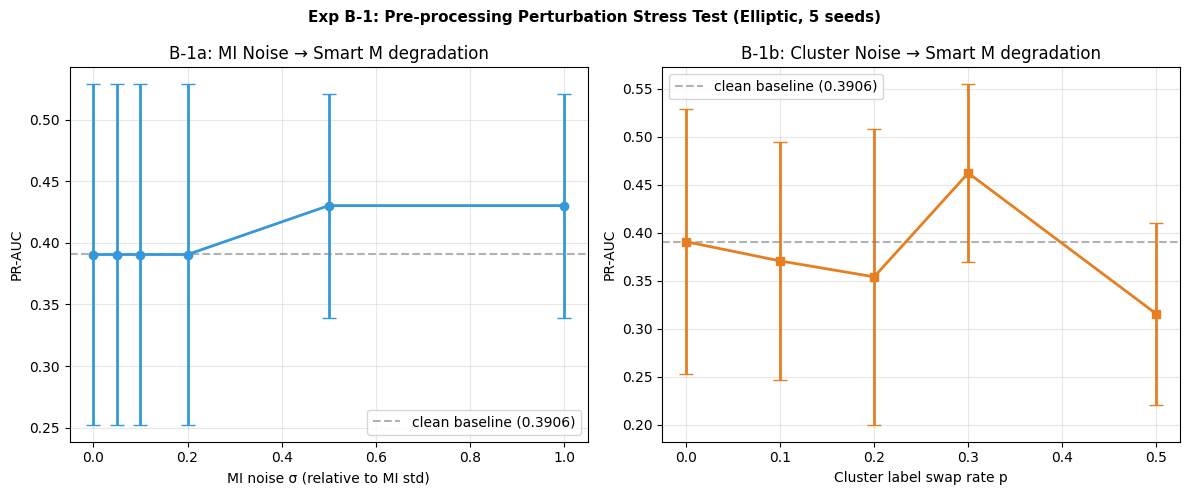


Degradation slopes:
  MI noise   σ=0→1.0: 0.3906 → 0.4303  (Δ=+0.0397)
  Clust swap p=0→0.5: 0.3906 → 0.3152  (Δ=-0.0754)

Graceful MI degradation: True (|Δ| < 0.05)


In [6]:
BASELINE = 0.3906  # AISO Smart+Score from Exp 5 (clean)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# MI noise
ax = axes[0]
xs = list(mi_noise_results.keys())
ys = [np.mean(mi_noise_results[s]) for s in xs]
es = [np.std(mi_noise_results[s])  for s in xs]
ax.errorbar(xs, ys, yerr=es, marker='o', capsize=5, color='#3498db', linewidth=2)
ax.axhline(BASELINE, color='gray', linestyle='--', alpha=0.6, label=f'clean baseline ({BASELINE:.4f})')
ax.set_xlabel('MI noise σ (relative to MI std)')
ax.set_ylabel('PR-AUC')
ax.set_title('B-1a: MI Noise → Smart M degradation')
ax.legend(); ax.grid(alpha=0.3)

# Cluster noise
ax = axes[1]
xs2 = list(swap_results.keys())
ys2 = [np.mean(swap_results[p]) for p in xs2]
es2 = [np.std(swap_results[p])  for p in xs2]
ax.errorbar(xs2, ys2, yerr=es2, marker='s', capsize=5, color='#e67e22', linewidth=2)
ax.axhline(BASELINE, color='gray', linestyle='--', alpha=0.6, label=f'clean baseline ({BASELINE:.4f})')
ax.set_xlabel('Cluster label swap rate p')
ax.set_ylabel('PR-AUC')
ax.set_title('B-1b: Cluster Noise → Smart M degradation')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Exp B-1: Pre-processing Perturbation Stress Test (Elliptic, 5 seeds)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('exp_b1_perturbation.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nDegradation slopes:')
print(f'  MI noise   σ=0→1.0: {ys[0]:.4f} → {ys[-1]:.4f}  (Δ={ys[-1]-ys[0]:+.4f})')
print(f'  Clust swap p=0→0.5: {ys2[0]:.4f} → {ys2[-1]:.4f}  (Δ={ys2[-1]-ys2[0]:+.4f})')
graceful_mi = abs(ys[-1]-ys[0]) < 0.05
print(f'\nGraceful MI degradation: {graceful_mi} (|Δ| < 0.05)')